In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import torch
from PIL import Image
from pyquaternion import Quaternion
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud
from torchvision.transforms import v2

from vigt import ViGTHFConfig, ViGTForInference
from vigt.rendering import ImplicitOccupancyRenderer, PinholeCamera, render_points, render_voxels
from safetensors.torch import load_file as safetensors_load_file

DEVICE = torch.device("cuda")
REPO_ROOT = Path("../")
assert torch.cuda.is_available(), "This notebook expects CUDA."
print("Using device:", DEVICE)


/home/jovyan/.mlspace/envs/test_release/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
# 1) NuScenes wrapper
CAM_CHANNELS = [
    "CAM_FRONT_LEFT",
    "CAM_FRONT",
    "CAM_FRONT_RIGHT",
    "CAM_BACK_LEFT",
    "CAM_BACK",
    "CAM_BACK_RIGHT",
]


class NuScenesToolkitWrapper:
    def __init__(self, nusc: NuScenes):
        self.nusc = nusc

    def load_camera_rig(self, sample_token: str):
        sample = self.nusc.get("sample", sample_token)
        rig = []
        for channel in CAM_CHANNELS:
            sd_token = sample["data"][channel]
            sd = self.nusc.get("sample_data", sd_token)
            image_path = Path(self.nusc.dataroot) / sd["filename"]
            image = np.asarray(Image.open(image_path).convert("RGB"))
            rig.append({"channel": channel, "image": image})
        return rig

    def load_origins_dirs_ego(
        self,
        sample_token: str,
        max_points: int = 120000,
        return_ranges: bool = False,
    ):
        sample = self.nusc.get("sample", sample_token)
        lidar_token = sample["data"]["LIDAR_TOP"]
        sd = self.nusc.get("sample_data", lidar_token)
        cs = self.nusc.get("calibrated_sensor", sd["calibrated_sensor_token"])

        lidar_path = self.nusc.get_sample_data_path(lidar_token)
        cloud = LidarPointCloud.from_file(lidar_path)
        pts_lidar = cloud.points[:3].T.astype(np.float32)

        if max_points is not None and pts_lidar.shape[0] > max_points:
            keep = np.random.choice(pts_lidar.shape[0], max_points, replace=False)
            pts_lidar = pts_lidar[keep]

        # lidar -> ego
        q_se = Quaternion(cs["rotation"]).rotation_matrix.astype(np.float32)
        t_se = np.asarray(cs["translation"], dtype=np.float32)
        pts_ego = pts_lidar @ q_se.T + t_se

        # Filter ego-box points before building input rays.
        x = pts_ego[:, 0]
        y = pts_ego[:, 1]
        in_box = (x > -1.0) & (x < 3.5) & (np.abs(y) < 1.0)
        pts_ego = pts_ego[~in_box]

        # Ray origins and directions in ego frame.
        origin_ego = t_se
        origins = np.repeat(origin_ego[None, :], pts_ego.shape[0], axis=0)
        dirs = pts_ego - origins
        ranges = np.linalg.norm(dirs, axis=1, keepdims=True).clip(min=1e-8)
        dirs = dirs / ranges

        origins_t = torch.from_numpy(origins)
        dirs_t = torch.from_numpy(dirs)
        if return_ranges:
            return origins_t, dirs_t, torch.from_numpy(ranges[:, 0])
        return origins_t, dirs_t


def load_camera_rig(nusc: NuScenes, sample_token: str):
    return NuScenesToolkitWrapper(nusc).load_camera_rig(sample_token)


def load_lidar_rays_ego(nusc: NuScenes, sample_token: str, max_points: int = 120000):
    return NuScenesToolkitWrapper(nusc).load_origins_dirs_ego(sample_token, max_points=max_points)


def load_lidar_points_ego(nusc: NuScenes, sample_token: str, max_points: int = 60000):
    origins, dirs, ranges = NuScenesToolkitWrapper(nusc).load_origins_dirs_ego(
        sample_token,
        max_points=max_points,
        return_ranges=True,
    )
    return origins + dirs * ranges.unsqueeze(-1)


def show_camera_rig(rig):
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    for ax, item in zip(axes.flatten(), rig):
        ax.imshow(item["image"])
        ax.set_title(item["channel"])
        ax.axis("off")
    plt.tight_layout()
    plt.show()


Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.500 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


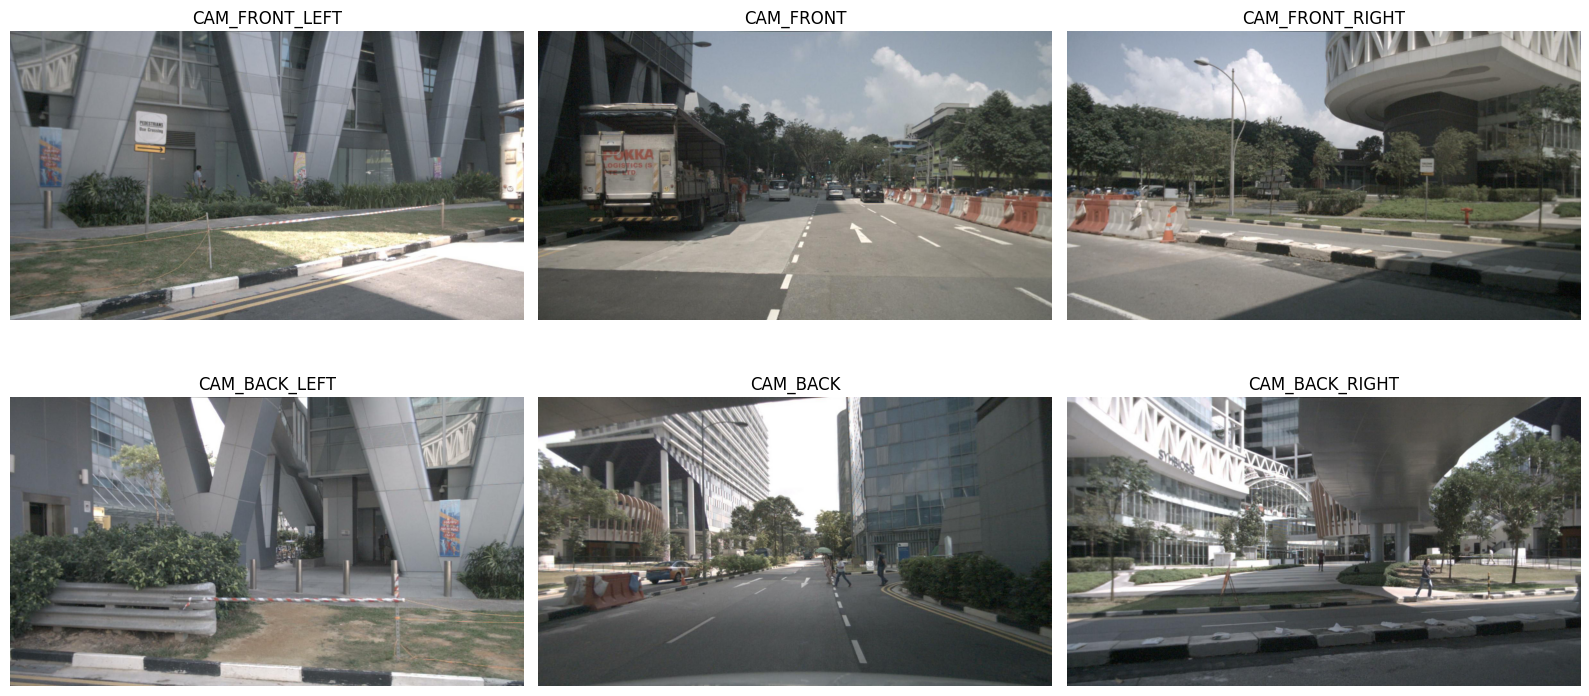

In [3]:
NUSCENES_ROOT = REPO_ROOT / "data" # <-- set your path
NUSCENES_VERSION = "v1.0-mini"       

nusc = NuScenes(version=NUSCENES_VERSION, dataroot=NUSCENES_ROOT, verbose=True)

scene = nusc.scene[0]
sample_token = scene["first_sample_token"]
rig = load_camera_rig(nusc, sample_token)
show_camera_rig(rig)

front_item = next(x for x in rig if x["channel"] == "CAM_FRONT")

In [4]:
# 2) Preprocessing and model input formatting

def default_transforms(shortest_max_size=192):
    return v2.Compose([
        v2.ToImage(),
        v2.Resize(size=shortest_max_size),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        v2.ToPureTensor()
    ])


def build_model_sample_from_rig(rig, transform):
    images = []
    camera_names = []
    for item in rig:
        images.append(transform(item["image"]))  # [C, H, W]
        camera_names.append(item["channel"])

    front_camera_idx = camera_names.index("CAM_FRONT")
    return {
        "images": images,
        "front_camera_idx": front_camera_idx,
    }

transform = default_transforms()
sample_for_model = build_model_sample_from_rig(rig, transform)
print("Num cameras:", len(sample_for_model["images"]))
print("One processed image shape:", tuple(sample_for_model["images"][0].shape))


/home/jovyan/.mlspace/envs/test_release/lib/python3.10/site-packages/torchvision/transforms/v2/functional/_type_conversion.py:14: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  output = torch.from_numpy(np.atleast_3d(inpt)).permute((2, 0, 1)).contiguous()


Num cameras: 6
One processed image shape: (3, 192, 341)


In [ ]:
# 3) model initialization 
VIGT_WEIGHTS_PATH = REPO_ROOT / "model.safetensors"

if not VIGT_WEIGHTS_PATH.exists():
    from huggingface_hub import hf_hub_download
    print("Downloading ViGT weights from Hugging Face...")
    VIGT_WEIGHTS_PATH = hf_hub_download(
        repo_id="whesense/ViGT",
        filename="model.safetensors",
        local_dir=str(REPO_ROOT),
    )

model = ViGTForInference(config=ViGTHFConfig())
state_dict = safetensors_load_file(str(VIGT_WEIGHTS_PATH), device="cpu")
model.load_state_dict(state_dict, strict=True)
model = model.to(DEVICE)
model.eval()

sample_for_model_device = {
    "images": [img.to(DEVICE) for img in sample_for_model["images"]],
    "front_camera_idx": sample_for_model["front_camera_idx"],
}

occupancy_fn = model.model.build_occupancy_fn(sample_for_model_device)
print("Model initialized.")


/home/jovyan/.mlspace/envs/test_release/lib/python3.10/site-packages/moge/model/v1.py:172: UserWarning: The following deprecated/invalid arguments are ignored: {'output_mask': True, 'split_head': True}
  warnings.warn(f"The following deprecated/invalid arguments are ignored: {deprecated_kwargs}")
/home/jovyan/users/shirokov/airi/ViGT/vigt/vigt_hf.py:89: UserWarning: tinycudann is not installed; using Identity query encoding.
  decoder = ImplicitDecoder(


Model initialized.


In [8]:
# 4) Point rendering

# LiDAR rays from NuScenes sample in ego coordinates.
origins, dirs = load_lidar_rays_ego(nusc, sample_token)
pointmap = render_points(
    occupancy_fn=occupancy_fn,
    ray_origins=origins.to(DEVICE),
    ray_dirs=dirs.to(DEVICE),
    roi=model.model.roi,
)

pts = pointmap.detach().cpu().numpy()

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=pts[:, 0],
            y=pts[:, 1],
            z=pts[:, 2],
            mode="markers",
            marker=dict(size=1.2, color=pts[:, 2], colorscale="Viridis", opacity=0.8),
        )
    ]
)
fig.update_layout(
    title="Interactive point cloud from render_points",
    scene=dict(aspectmode="data", xaxis_title="X", yaxis_title="Y", zaxis_title="Z"),
    height=700,
)
fig.show()


In [ ]:
# 5) Voxel rendering
VOXEL_GRID_SHAPE = (200, 200, 16)
VOXEL_SIZE = 0.4
POINTS_PER_VOXEL = 8

voxel_tensor = render_voxels(
    occupancy_fn=occupancy_fn,
    roi=model.model.roi,
    grid_shape=VOXEL_GRID_SHAPE,
    voxel_size=VOXEL_SIZE,
    points_per_voxel=POINTS_PER_VOXEL,
    threshold=0.5,
    device=DEVICE,
)
print("Voxel tensor shape:", tuple(voxel_tensor.shape))

occupied_idx = voxel_tensor.nonzero(as_tuple=False).detach().cpu().numpy()
if occupied_idx.size == 0:
    print("No occupied voxels to display")
else:
    vs = float(VOXEL_SIZE)
    roi_min = np.asarray(model.model.roi["min"], dtype=np.float32)
    centers = roi_min + (occupied_idx.astype(np.float32) + 0.5) * vs

    corners = np.array([
        [-0.5, -0.5, -0.5], [ 0.5, -0.5, -0.5], [ 0.5,  0.5, -0.5], [-0.5,  0.5, -0.5],
        [-0.5, -0.5,  0.5], [ 0.5, -0.5,  0.5], [ 0.5,  0.5,  0.5], [-0.5,  0.5,  0.5],
    ], dtype=np.float32) * vs
    faces_local = np.array([
        [0, 1, 2], [0, 2, 3], [4, 5, 6], [4, 6, 7],
        [0, 1, 5], [0, 5, 4], [1, 2, 6], [1, 6, 5],
        [2, 3, 7], [2, 7, 6], [3, 0, 4], [3, 4, 7],
    ], dtype=np.int32)

    vertices = (centers[:, None, :] + corners[None, :, :]).reshape(-1, 3)
    faces = (np.arange(len(centers), dtype=np.int32)[:, None, None] * 8 + faces_local[None, :, :]).reshape(-1, 3)
    face_heights = np.repeat(centers[:, 2], faces_local.shape[0])

    fig_voxels = go.Figure(go.Mesh3d(
        x=vertices[:, 0], y=vertices[:, 1], z=vertices[:, 2],
        i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
        intensity=face_heights, intensitymode="cell", colorscale="Turbo",
        opacity=0.95, flatshading=True,
        lighting=dict(ambient=1.0, diffuse=0.0, specular=0.0, roughness=1.0, fresnel=0.0),
        colorbar=dict(title="Height (m)"),
        name="occupied voxels",
    ))
    fig_voxels.update_layout(
        title="Interactive voxel occupancy",
        scene=dict(aspectmode="data", xaxis_title="X", yaxis_title="Y", zaxis_title="Z", bgcolor="rgba(10, 10, 20, 1.0)"),
        paper_bgcolor="rgba(10, 10, 20, 1.0)",
        font=dict(color="white"),
        height=760,
    )
    fig_voxels.show()


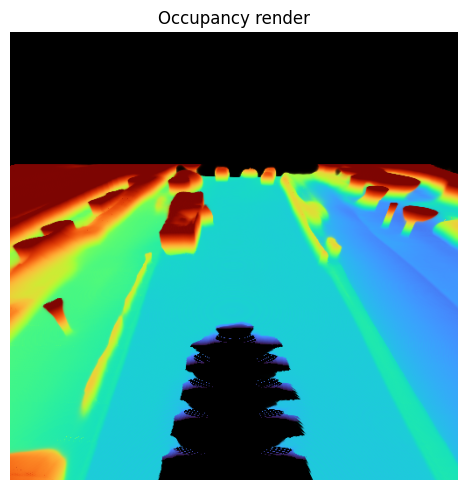

In [16]:
# 6) Occupancy rendering
roi = model.model.roi
renderer = ImplicitOccupancyRenderer(
    viewport=None,
    render_step_size=0.05,
    roi_vmin=(roi["min"][0], roi["min"][1], roi["min"][2]),
    roi_vmax=(roi["max"][0], roi["max"][1], roi["max"][2]),
).to(DEVICE)

viz_camera = PinholeCamera.lookat(
    eye=[-4.0, 0.0, 10.0],
    at=[12.0, 0.0, 0.0],
    up=[0.0, 0.0, 1.0],
    fov=90.0,
    viewport=(512, 512),
)
viz_camera.world_se3_camera.to(DEVICE)
viz_camera.intrinsics = viz_camera.intrinsics.to(DEVICE)

rgb = renderer(occupancy_fn, viz_camera).detach().cpu().numpy()

plt.figure(figsize=(10, 5))
plt.imshow(np.clip(rgb, 0.0, 1.0))
plt.title("Occupancy render")
plt.axis("off")
plt.tight_layout()
plt.show()
